<a href="https://www.kaggle.com/code/hasnainaliasghar941/fashion-mnist-model-training-ann?scriptVersionId=351247996" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


# Basic Imports

In [2]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## GPU Check

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [4]:
torch.manual_seed(42)

In [5]:
df = pd.read_csv("/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


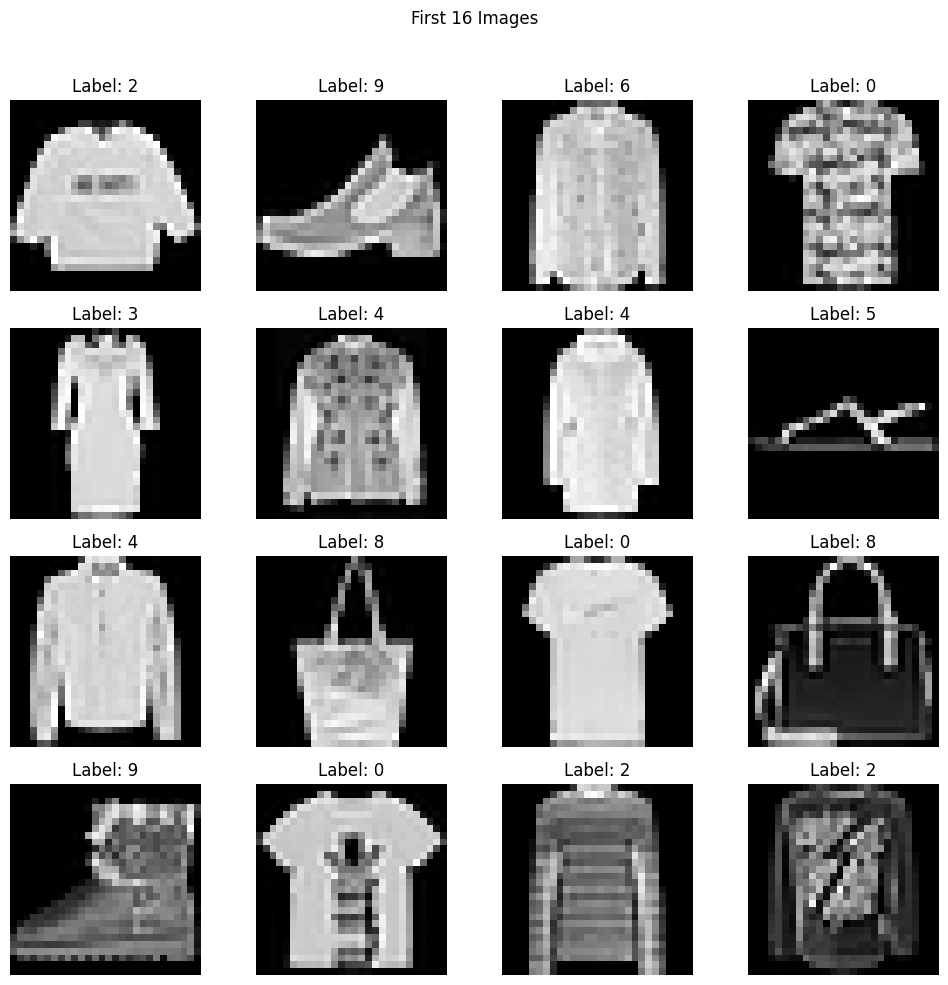

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images")

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img, cmap="gray")
  ax.axis("off")
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout(rect = [0,0,1,0.96])
plt.show()

In [7]:
X = df.drop(columns = ["label"])
y = df["label"]

## Teain Test Split

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state = 42, test_size = 0.2)

In [9]:
X_train.shape

(48000, 784)

In [10]:
X_train = X_train/255.0
X_test = X_test/255.0

In [11]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
48572,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
38696,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
13611,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
35213,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
31766,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.003922,0.0,...,0.000000,0.000000,0.003922,0.000000,0.043137,0.145098,0.023529,0.000000,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54343,0.0,0.0,0.0,0.0,0.0,0.011765,0.027451,0.000000,0.000000,0.0,...,0.682353,0.705882,0.768627,0.921569,0.000000,0.000000,1.000000,0.898039,0.65098,0.0
38158,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
860,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
15795,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.007843,0.000000,0.0,...,0.368627,0.290196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0


In [12]:
#Custom DatasetClass
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features.to_numpy(), dtype = torch.float32)
    self.labels = torch.tensor(labels.to_numpy(), dtype= torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

In [13]:
print(CustomDataset)

<class '__main__.CustomDataset'>


In [14]:
type(X_train)

pandas.core.frame.DataFrame

In [15]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

## Objective Function

In [16]:
class MyNN(nn.Module):
    def __init__(self,input_dim,output_dim, num_hidden_layers, neurons_per_layer,dropout_rate):
        super().__init__()

        layers = []
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim = neurons_per_layer

        layers.append(nn.Linear(neurons_per_layer, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x)

In [17]:
def objective(trial):
    #hyper parameter tuning by optuna
    num_hidden_layers = trial.suggest_int("num_hidden_layers",1,4)
    neurons_per_layer = trial.suggest_categorical("neurons_per_layer",[64,128,256])
    epochs = trial.suggest_int("epochs",10,50,step=10)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log = True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0,0.3, step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [16,32,64,128])
    optimizer_name = trial.suggest_categorical("optimizer",["Adam","SGD","RMSprop"])
    weight_decay= trial.suggest_float("weight_decay", 1e-5,1e-3, log=True)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, pin_memory=True)

    #model init
    input_dim = 784
    output_dim = 10

    model = MyNN(input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate)
    model.to(device)

    #Optimizer Selection
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
         optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay = weight_decay)
    elif optimizer_name == "SGD":
         optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay = weight_decay)
    else:
         optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay = weight_decay)
    
    #training loop
    for epoch in range(epochs):
      total_epoch_loss = 0
      for batch_features, batch_labels in train_loader:
        #Customizing to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        #forward pass
        outputs = model(batch_features)
        
        #calculate loss
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        #back propagation
        loss.backward()
        
        #update grads
        optimizer.step()

    #Evaluation
    model.eval()
    
    total = 0
    correct = 0
    
    with torch.no_grad():
      for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
    
    accuracy = 100 * correct / total

    return accuracy

In [18]:
! pip install optuna


In [19]:
import optuna
study = optuna.create_study(direction = 'maximize')


[I 2026-09-20 07:30:21,413] A new study created in memory with name: no-name-370393b1-030c-4144-88a4-0bac5e861661


In [20]:
study.optimize(objective, n_trials=50)

[I 2026-09-20 07:31:22,468] Trial 0 finished with value: 88.24166666666666 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 256, 'epochs': 10, 'learning_rate': 0.00019447929754167308, 'dropout_rate': 0.3, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 6.77843485730104e-05}. Best is trial 0 with value: 88.24166666666666.
[I 2026-09-20 07:33:15,980] Trial 1 finished with value: 88.775 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 256, 'epochs': 40, 'learning_rate': 0.0007366555495370107, 'dropout_rate': 0.0, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.000514490361431679}. Best is trial 1 with value: 88.775.
[I 2026-09-20 07:34:02,047] Trial 2 finished with value: 85.43333333333334 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 64, 'epochs': 10, 'learning_rate': 0.0015712400386267101, 'dropout_rate': 0.1, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0009448592470591701}. Best is trial 1 with value: 88.775.
[I 2

In [21]:
study.best_value

90.15833333333333

In [22]:
study.best_params

{'num_hidden_layers': 2,
 'neurons_per_layer': 256,
 'epochs': 20,
 'learning_rate': 0.0005604457754212455,
 'dropout_rate': 0.2,
 'batch_size': 16,
 'optimizer': 'Adam',
 'weight_decay': 2.0347908315671863e-05}